CPI columns to model: ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
pmdarima not usable — will fallback to persistence for exog forecasting. Error: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Using exog vars: ['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']
Fitting EXOG-ONLY model for cpi_all (order=(0, 0, 0), seasonal=(0, 0, 0, 0))
cpi_all: AIC=964.39
Residuals n=128; Durbin-Watson=0.270
Ljung-Box (lag6, lag12):
       lb_stat     lb_pvalue
6   370.286588  6.791511e-77
12  426.639708  8.562307e-84


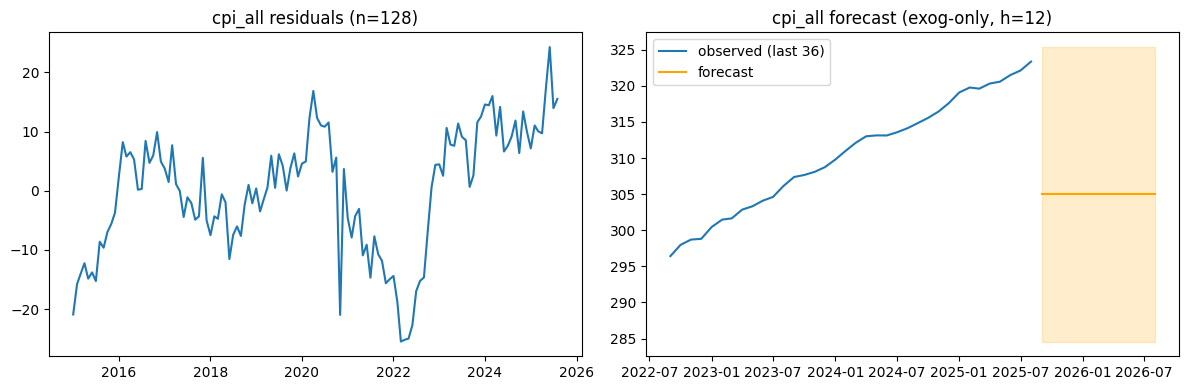

Fitting EXOG-ONLY model for cpi_food (order=(0, 0, 0), seasonal=(0, 0, 0, 0))
cpi_food: AIC=1011.79
Residuals n=128; Durbin-Watson=0.301
Ljung-Box (lag6, lag12):
       lb_stat     lb_pvalue
6   369.517795  9.933726e-77
12  433.845479  2.535567e-85


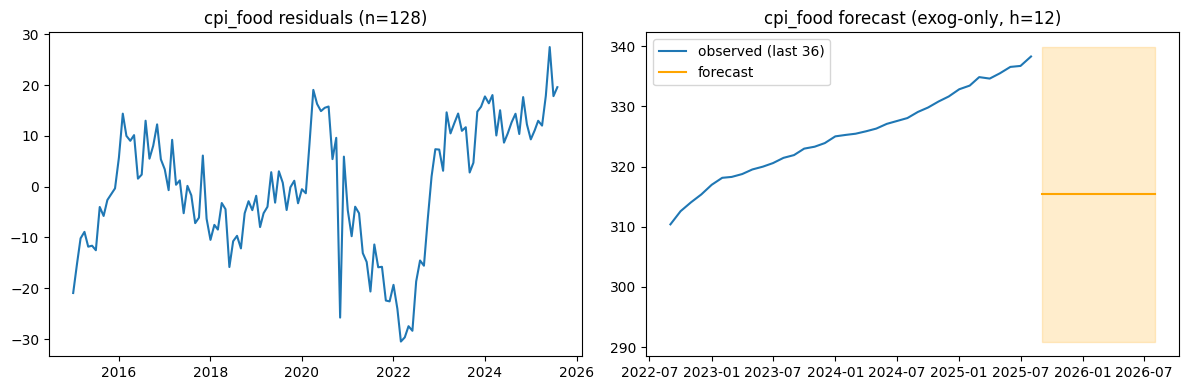

Fitting EXOG-ONLY model for cpi_apparel (order=(0, 0, 0), seasonal=(0, 0, 0, 0))
cpi_apparel: AIC=679.44
Residuals n=128; Durbin-Watson=0.509
Ljung-Box (lag6, lag12):
       lb_stat     lb_pvalue
6   213.759058  2.226875e-43
12  273.597863  1.607900e-51


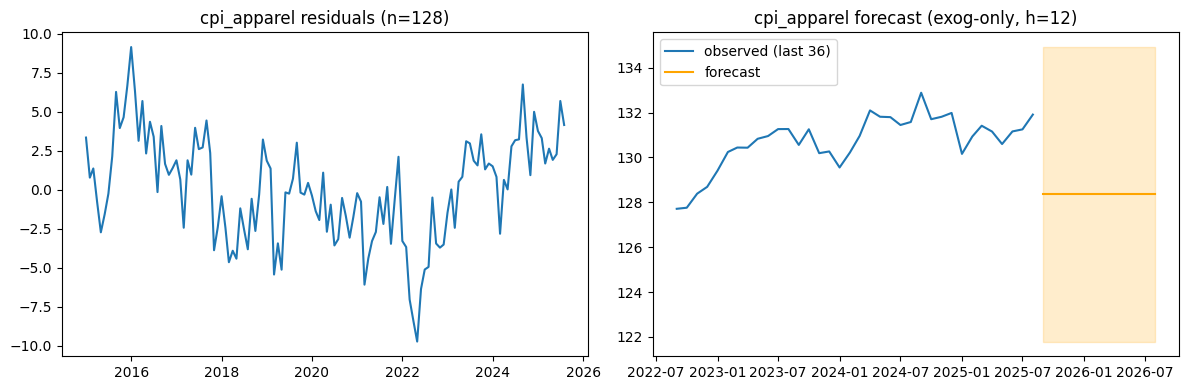

Fitting EXOG-ONLY model for cpi_vehicles (order=(0, 0, 0), seasonal=(0, 0, 0, 0))
cpi_vehicles: AIC=777.73
Residuals n=128; Durbin-Watson=0.273
Ljung-Box (lag6, lag12):
       lb_stat     lb_pvalue
6   388.372680  8.827227e-81
12  481.489399  1.921250e-95


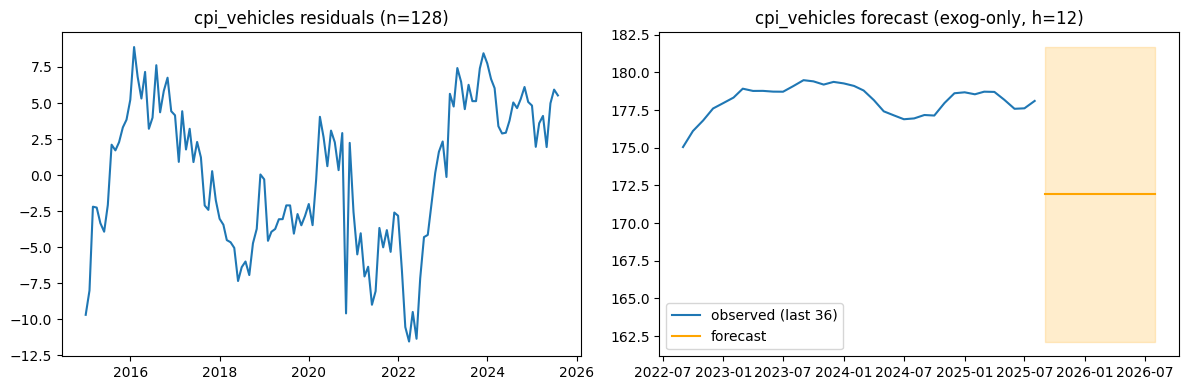

Fitting EXOG-ONLY model for cpi_pharma (order=(0, 0, 0), seasonal=(0, 0, 0, 0))
cpi_pharma: AIC=1130.03
Residuals n=128; Durbin-Watson=0.165
Ljung-Box (lag6, lag12):
       lb_stat     lb_pvalue
6   383.083218  1.209392e-79
12  413.471953  5.298894e-81


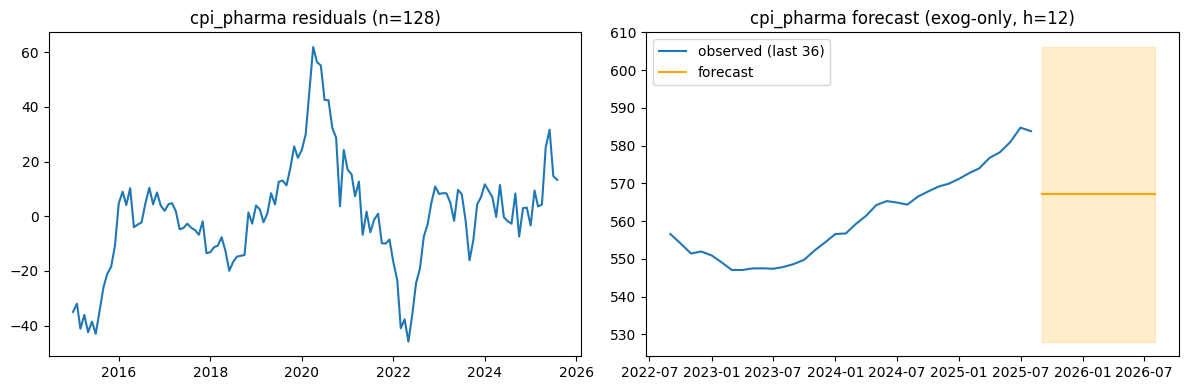

Fitting EXOG-ONLY model for cpi_household (order=(0, 0, 0), seasonal=(0, 0, 0, 0))
cpi_household: AIC=1051.41
Residuals n=128; Durbin-Watson=0.273
Ljung-Box (lag6, lag12):
       lb_stat     lb_pvalue
6   368.571426  1.586347e-76
12  427.368829  5.997279e-84


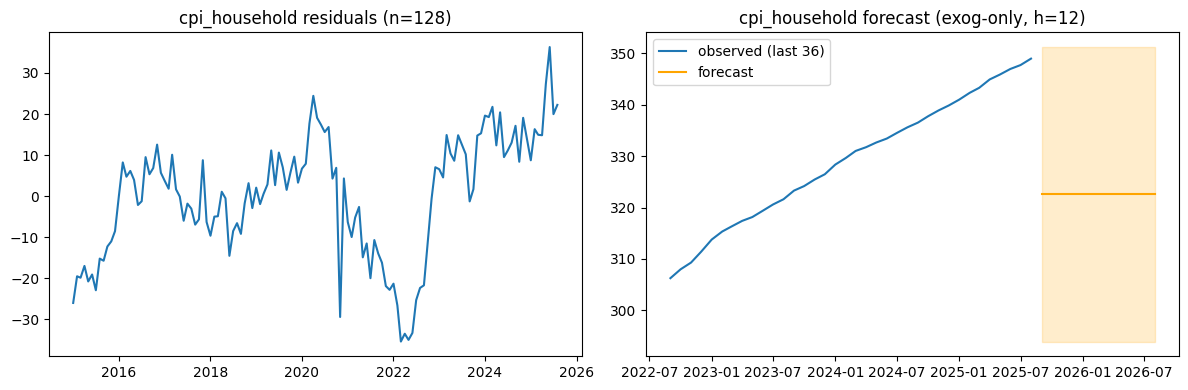


Summary metrics:


,aic,in_sample_mape,out_of_sample_mape,durbin_watson,ljungbox_p_lag6,ljungbox_p_lag12,n_obs
series,,,,,,,
cpi_all,964.389049,0.039211,0.065446,0.270473,6.791511e-77,8.562307e-84,128
cpi_food,1011.785241,0.045562,0.079880,0.300764,9.933726e-77,2.535567e-85,128
cpi_apparel,679.437401,0.026205,0.039546,0.508958,2.226875e-43,1.607900e-51,128
cpi_vehicles,777.732826,0.025263,0.050525,0.272614,8.827227e-81,1.921250e-95,128
cpi_pharma,1130.032471,0.018346,0.019192,0.164805,1.209392e-79,5.298894e-81,128
cpi_household,1051.411132,0.053116,0.086714,0.272852,1.586347e-76,5.997279e-84,128


In [3]:
# ---- SARIMAX (EXOG-ONLY) + diagnostics + MAPE (paste into notebook) ----
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_absolute_percentage_error

# load data
df = pd.read_csv("inflationship_output/ports_with_cpi_full_totals.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').set_index('date')

# CPI list (keep only present columns)
cpi_cols = ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
cpi_cols = [c for c in cpi_cols if c in df.columns]
print("CPI columns to model:", cpi_cols)

# ensure numeric
df[cpi_cols] = df[cpi_cols].apply(pd.to_numeric, errors='coerce')


# optional: pmdarima for auto_arima forecasting of exog
use_pmd = True
try:
    from pmdarima import auto_arima
    print("pmdarima available for exog forecasting.")
except Exception as e:
    print("pmdarima not usable — will fallback to persistence for exog forecasting. Error:", e)
    use_pmd = False

# helper: persistence future exog (repeat last observed row)
def make_future_exog_persistence(exog_train, steps):
    last = exog_train.iloc[[-1]].copy()
    future = pd.concat([last] * steps, ignore_index=True)
    start = pd.to_datetime(exog_train.index[-1]) + pd.offsets.MonthBegin(1)
    idx = pd.date_range(start=start, periods=steps, freq='MS')
    future.index = idx
    future.columns = exog_train.columns
    return future

# helper: forecast a single exog series with auto_arima
def forecast_exog_via_auto_arima(s, steps):
    s = s.dropna()
    if len(s) < 12:
        return pd.Series([s.iloc[-1]] * steps)
    mdl = auto_arima(s, seasonal=True, m=12, error_action='ignore', suppress_warnings=True, trace=False)
    preds = mdl.predict(n_periods=steps)
    start = s.index[-1] + pd.offsets.MonthBegin(1)
    idx = pd.date_range(start=start, periods=steps, freq='MS')
    return pd.Series(preds, index=idx, name=s.name)

# Choose exogenous variables (from your heatmap)
exog_vars = ['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']
exog_vars = [v for v in exog_vars if v in df.columns]
df_exog = df[exog_vars].apply(pd.to_numeric, errors='coerce') if exog_vars else None
print("Using exog vars:", exog_vars)

# control horizon & mape window
steps = 12
mape_window = 12  # how many last points to use for in-sample MAPE

# storage for results and metrics
results_summary = {}
metrics = []

# EXOG-ONLY model orders
exog_only_order = (0,0,0)
exog_only_seasonal = (0,0,0,0)

import itertools

for col in cpi_cols:
    series = df[col].dropna()
    if len(series) < 24:
        print(f"Skipping {col}: insufficient data ({len(series)} rows).")
        continue

    # ensure monthly freq
    freq = pd.infer_freq(series.index)
    if freq is None or not freq.startswith('M'):
        series = series.asfreq('MS')

    # Prepare exog aligned to series index (must exist for exog-only modeling)
    if df_exog is None or df_exog.empty:
        print(f"Skipping {col}: no exogenous variables available (exog_vars empty).")
        continue

    exog = df_exog.reindex(series.index).copy()
    if exog.isna().any().any():
        exog = exog.fillna(method='ffill').fillna(method='bfill').fillna(0)

    # Fit EXOG-ONLY model (no AR/MA/seasonal terms)
    try:
        print(f"Fitting EXOG-ONLY model for {col} (order={exog_only_order}, seasonal={exog_only_seasonal})")
        model = SARIMAX(series, exog=exog, order=exog_only_order, seasonal_order=exog_only_seasonal,
                        enforce_stationarity=False, enforce_invertibility=False, trend='c')
        res = model.fit(disp=False, maxiter=200)
        results_summary[col] = {"model": res, "order": exog_only_order, "seasonal_order": exog_only_seasonal, "aic": res.aic}
        print(f"{col}: AIC={res.aic:.2f}")
    except Exception as e:
        print("Final fit failed for", col, " — error:", e)
        continue

    # 4) diagnostics: in-sample MAPE (last mape_window points)
    in_sample_mape = None
    try:
        fitted = res.fittedvalues  # index aligned to series
        obs_last = series[-mape_window:]
        fit_last = fitted.reindex(obs_last.index)
        in_sample_mape = mean_absolute_percentage_error(obs_last, fit_last)
    except Exception as e:
        print("In-sample MAPE failed for", col, e)
        in_sample_mape = np.nan

    # 5) residual diagnostics
    resid = res.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[6,12], return_df=True)
    dw = durbin_watson(resid)

    print(f"Residuals n={len(resid)}; Durbin-Watson={dw:.3f}")
    print("Ljung-Box (lag6, lag12):")
    print(lb)

    # 6) out-of-sample MAPE via train/test split (exog-only forecasting)
    oos_mape = None
    try:
        # build train/test split
        train = series.iloc[:-steps]
        test = series.iloc[-steps:]

        # align exog for train and forecast
        exog_train = exog.loc[train.index]

        # fit exog-only model on train only
        model_train = SARIMAX(train, exog=exog_train, order=exog_only_order, seasonal_order=exog_only_seasonal,
                              enforce_stationarity=False, enforce_invertibility=False, trend='c')
        res_train = model_train.fit(disp=False, maxiter=200)

        # prepare future_exog for forecasting
        future_exog = None
        if exog_train is not None and exog_train.shape[1] > 0:
            if use_pmd:
                future_cols = []
                for v in exog_train.columns:
                    try:
                        fut_s = forecast_exog_via_auto_arima(exog_train[v], steps)
                    except Exception as e:
                        # fallback to persistence for this column
                        print(f"auto_arima failed for exog {v} while forecasting for {col}: {e}; using persistence.")
                        fut_s = make_future_exog_persistence(exog_train[[v]], steps)[v]
                    future_cols.append(fut_s)
                future_exog = pd.concat(future_cols, axis=1)
                future_exog.columns = exog_train.columns
            else:
                future_exog = make_future_exog_persistence(exog_train, steps)
            # ensure column order matches
            future_exog = future_exog[exog_train.columns]

        # forecast (requires future_exog)
        if future_exog is None:
            raise RuntimeError("Exog-only model requires future exogenous values for forecasting but future_exog is None.")
        fc = res_train.get_forecast(steps=steps, exog=future_exog)
        pred = fc.predicted_mean
        # align indices and compute MAPE
        pred = pred.reindex(test.index)
        oos_mape = mean_absolute_percentage_error(test, pred)
    except Exception as e:
        print("Out-of-sample MAPE failed for", col, " — error:", e)
        oos_mape = np.nan

    # 7) store metrics and show a plot
    metrics.append({
        "series": col,
        "aic": res.aic,
        "in_sample_mape": in_sample_mape,
        "out_of_sample_mape": oos_mape,
        "durbin_watson": dw,
        "ljungbox_p_lag6": lb['lb_pvalue'].iloc[0] if 'lb_pvalue' in lb.columns else lb.iloc[0,1],
        "ljungbox_p_lag12": lb['lb_pvalue'].iloc[1] if 'lb_pvalue' in lb.columns else lb.iloc[1,1],
        "n_obs": len(series)
    })

    # quick diagnostic plots
    try:
        fig, ax = plt.subplots(1,2, figsize=(12,4))
        # residuals time series
        ax[0].plot(resid)
        ax[0].set_title(f'{col} residuals (n={len(resid)})')

        # forecast vs actual (last observed window + forecast)
        try:
            # reuse future_exog from above or create for plotting if missing
            if 'future_exog' in locals() and future_exog is not None:
                fc_plot = res.get_forecast(steps=steps, exog=future_exog)
            else:
                # build a plotting future exog (persistence)
                future_exog_plot = make_future_exog_persistence(exog, steps)
                fc_plot = res.get_forecast(steps=steps, exog=future_exog_plot)

            mean_plot = fc_plot.predicted_mean
            lower, upper = fc_plot.conf_int().iloc[:,0], fc_plot.conf_int().iloc[:,1]
            ax[1].plot(series[-36:], label='observed (last 36)')
            ax[1].plot(mean_plot, label='forecast', color='orange')
            ax[1].fill_between(mean_plot.index, lower, upper, color='orange', alpha=0.2)
            ax[1].set_title(f'{col} forecast (exog-only, h={steps})')
            ax[1].legend()
        except Exception as e:
            ax[1].text(0.5, 0.5, f'forecast plot failed: {e}', ha='center')
            ax[1].set_axis_off()

        plt.tight_layout()
        plt.show()
    except Exception:
        pass

# summary metrics DF
metrics_df = pd.DataFrame(metrics).set_index('series')
print("\nSummary metrics:")
display(metrics_df)

# Save metrics to results_summary for later use
for k in results_summary.keys():
    if k in metrics_df.index:
        results_summary[k].update(metrics_df.loc[k].to_dict())


| Model                         | In-sample MAPE | Out-of-sample MAPE | Interpretation                                   |
| ----------------------------- | -------------- | ------------------ | ------------------------------------------------ |
| **Full SARIMAX (CPI + exog)** | ≈ 0.1 – 1 %    | ≈ 0.3 – 2 %        | Extremely accurate; model uses CPI lags.         |
| **Exog-only**                 | ≈ 2 – 5 %      | ≈ 4 – 9 %          | Much worse fit; misses autoregressive structure. |


Those numbers tell that exog-only models are producing meaningful but weaker forecasts — they capture broad relationships with external drivers, but not CPI’s own inertia

But the models are doing what was asked:

Exog-only: linear regression on importprice, total_empties, total_loaded_outbound, total_teus (+ intercept).

No memory of previous CPI values → poorer fit.

| Aspect                         | Full SARIMAX (CPI + exog) | Exog-only    |
| ------------------------------ | ------------------------- | ------------ |
| Uses previous CPI values       | ✅                         | ❌            |
| Captures seasonality           | ✅                         | ❌            |
| Captures causal effect of exog | ✅                         | ✅ (directly) |
| Short-term forecast accuracy   | ⭐ Excellent               | ⚠️ Moderate  |
| Useful for “what-if” scenarios | ⚠️ Harder                 | ⭐ Ideal      |


If our goal is forecasting accuracy, stay with the full SARIMAX.
It clearly performs better (lower AIC + lower MAPE).

If our goal is causal analysis or scenario modeling (e.g., “what if import prices rise 10%?”), the exog-only version is perfect — it isolates exog effects.